In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/navneet0094/jafee-dataset/README_FIRST.txt
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/NM.SA1.98.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/YM.SA3.57.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/KA.DI3.44.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/KM.AN2.18.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/MK.HA3.118.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/NM.FE2.111.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/TM.HA1.180.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/UY.FE2.153.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/UY.DI3.151.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/YM.NE2.50.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/TM.SU3.189.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/MK.NE3.115.tiff
/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe/MK.SA3.121.tiff
/kaggle/input/da

In [2]:
dataset_path = "//kaggle/input/datasets/navneet0094/jafee-dataset/"

print(os.listdir(dataset_path))

['jaffe', 'README_FIRST.txt']


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

data = []
labels = []

emotion_map = {
    'AN':0, 'DI':1, 'FE':2,
    'HA':3, 'SA':4, 'SU':5, 'NE':6
}

dataset_path = "/kaggle/input/datasets/navneet0094/jafee-dataset/jaffe"

for img_name in os.listdir(dataset_path):

    img_path = os.path.join(dataset_path, img_name)

    try:
        # grayscale
        img = Image.open(img_path).convert('L')

        # resize to 128x128
        img = img.resize((128,128))

        img = np.array(img)

        emotion = img_name.split('.')[1][:2]
        label = emotion_map[emotion]

        data.append(img)
        labels.append(label)

    except Exception as e:
        print("Error:", img_name)

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (213, 128, 128)
Labels: [0 1 2 3 4 5 6]


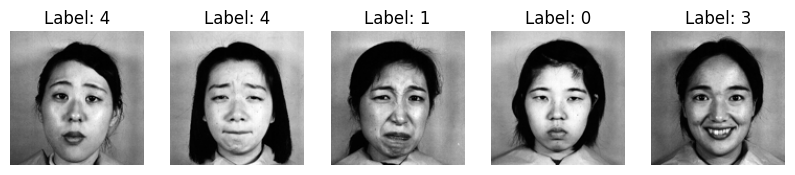

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(data[i], cmap='gray')
    plt.title(f"Label: {labels[i]}")
    plt.axis('off')

plt.show()

In [5]:
# HOG
from skimage.feature import hog

X_hog = []

for img in data:
    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )
    X_hog.append(features)

X_hog = np.array(X_hog)

print("HOG feature shape:", X_hog.shape)

HOG feature shape: (213, 8100)


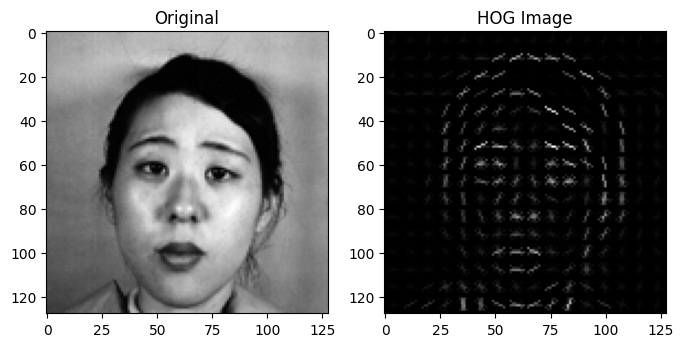

In [6]:
# HOG vis
sample_img = data[0]

features, hog_image = hog(
    sample_img,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2),
    visualize=True
)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(hog_image, cmap='gray')
plt.title("HOG Image")

plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear'))
])


In [9]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report



In [10]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess


# Load pretrained model (feature extractor)
mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

# VGG
vgg = VGG16(weights='imagenet', include_top=False, pooling='avg')

2026-05-27 07:45:20.237768: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779867920.432609      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779867920.490350      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779867920.967257      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779867920.967304      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779867920.967307      23 computation_placer.cc:177] computation placer alr

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
import cv2
import numpy as np

def extract_cnn_features(images, model):
    features = []
    
    for img in images:
        img = cv2.resize(img, (224,224))
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = preprocess_input(img)
    
        img = np.expand_dims(img, axis=0)
        
        feat = model.predict(img, verbose=0)
        features.append(feat.flatten())
    
    return np.array(features)

In [12]:
def extract_vgg_features(images, model):
    features = []
    
    for img in images:
        img = cv2.resize(img, (224,224))
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        img = vgg_preprocess(img)
        
        img = np.expand_dims(img, axis=0)
        feat = model.predict(img, verbose=0)
        
        features.append(feat.flatten())
    
    return np.array(features)

In [13]:
# MobileNet features
X_cnn = extract_cnn_features(data, mobilenet)

print("Mobilenet feature shape:", X_cnn.shape)

I0000 00:00:1779867948.983329      73 service.cc:152] XLA service 0x7bbbe8003910 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779867948.983371      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779867948.983376      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779867949.608275      73 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-27 07:45:57.865856: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 07:45:58.024150: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-27 07:45:58.157733: E external/local_xl

Mobilenet feature shape: (213, 1280)


In [14]:
# VGG features
X_vgg = extract_vgg_features(data, vgg)

print("VGG feature shape:", X_vgg.shape)

VGG feature shape: (213, 512)


In [15]:
# Hybrid CNN (VGG + MobileNet)
X_hybrid = np.concatenate([X_cnn, X_vgg], axis=1)

# HOG + Hybrid (final best)
X_final = np.concatenate([X_hog, X_hybrid], axis=1)

print("Hybrid shape:", X_hybrid.shape)
print("Final shape:", X_final.shape)

Hybrid shape: (213, 1792)
Final shape: (213, 9892)


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [17]:
from sklearn.metrics import classification_report

emotion_names = [
    'anger','disgust','fear',
    'happy','sadness','surprise','neutral'
]

def run_model(X, name):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        labels,
        test_size=0.3,
        stratify=labels,
        random_state=42
    )

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='linear'))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"\n{name} Accuracy:", acc)

    report = classification_report(
        y_test,
        y_pred,
        target_names=emotion_names,
        output_dict=True
    )

    return {
        'name': name,
        'accuracy': acc,
        'report': report,
        'y_test': y_test,
        'y_pred': y_pred
    }

In [18]:
# HOG + MobileNet
X_hog_cnn = np.concatenate([X_hog, X_cnn], axis=1)

# HOG + VGG
X_hog_vgg = np.concatenate([X_hog, X_vgg], axis=1)

print("HOG+CNN shape:", X_hog_cnn.shape)
print("HOG+VGG shape:", X_hog_vgg.shape)

HOG+CNN shape: (213, 9380)
HOG+VGG shape: (213, 8612)


In [19]:
results = []

results.append(run_model(X_hog, "HOG"))

results.append(run_model(X_cnn, "MobileNet"))

results.append(run_model(X_vgg, "VGG"))

results.append(run_model(X_hybrid, "VGG + MobileNet(Hybrid)"))

results.append(run_model(X_hog_vgg, "VGG + HOG"))

results.append(run_model(X_hog_cnn, "MobileNet + HOG"))

results.append(run_model(X_final, "Hog + Hybrid"))


HOG Accuracy: 0.84375

MobileNet Accuracy: 0.84375

VGG Accuracy: 0.65625

VGG + MobileNet(Hybrid) Accuracy: 0.796875

VGG + HOG Accuracy: 0.828125

MobileNet + HOG Accuracy: 0.875

Hog + Hybrid Accuracy: 0.828125


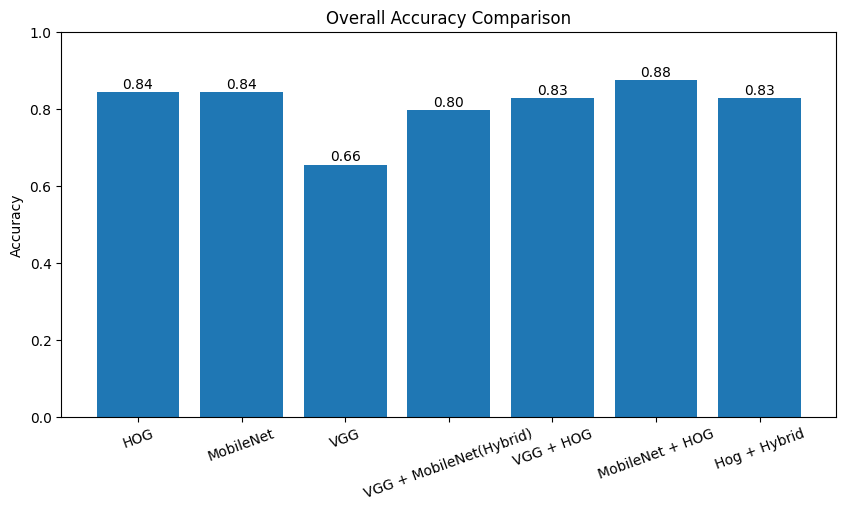

In [20]:
model_names = []
accuracies = []

for res in results:
    model_names.append(res['name'])
    accuracies.append(res['accuracy'])

plt.figure(figsize=(10,5))

bars = plt.bar(model_names, accuracies)

plt.ylim(0,1)

plt.title("Overall Accuracy Comparison")
plt.ylabel("Accuracy")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        f"{yval:.2f}",
        ha='center'
    )

plt.xticks(rotation=20)

plt.show()

In [21]:
import pandas as pd

emotion_f1 = pd.DataFrame()

for res in results:

    model_name = res['name']

    f1_scores = []

    for emotion in emotion_names:
        f1_scores.append(
            res['report'][emotion]['f1-score']
        )

    emotion_f1[model_name] = f1_scores

emotion_f1.index = emotion_names

print(emotion_f1)

               HOG  MobileNet       VGG  VGG + MobileNet(Hybrid)  VGG + HOG  \
anger     0.736842   0.900000  0.705882                 0.777778   0.736842   
disgust   0.857143   0.947368  0.800000                 0.761905   0.857143   
fear      0.823529   0.782609  0.782609                 0.727273   0.777778   
happy     0.888889   0.823529  0.571429                 0.888889   0.888889   
sadness   0.705882   0.625000  0.307692                 0.533333   0.625000   
surprise  0.941176   0.875000  0.705882                 0.941176   0.941176   
neutral   0.947368   0.941176  0.588235                 0.941176   0.947368   

          MobileNet + HOG  Hog + Hybrid  
anger            0.800000      0.736842  
disgust          0.900000      0.857143  
fear             0.842105      0.842105  
happy            0.947368      0.888889  
sadness          0.750000      0.705882  
surprise         0.875000      0.800000  
neutral          1.000000      0.947368  


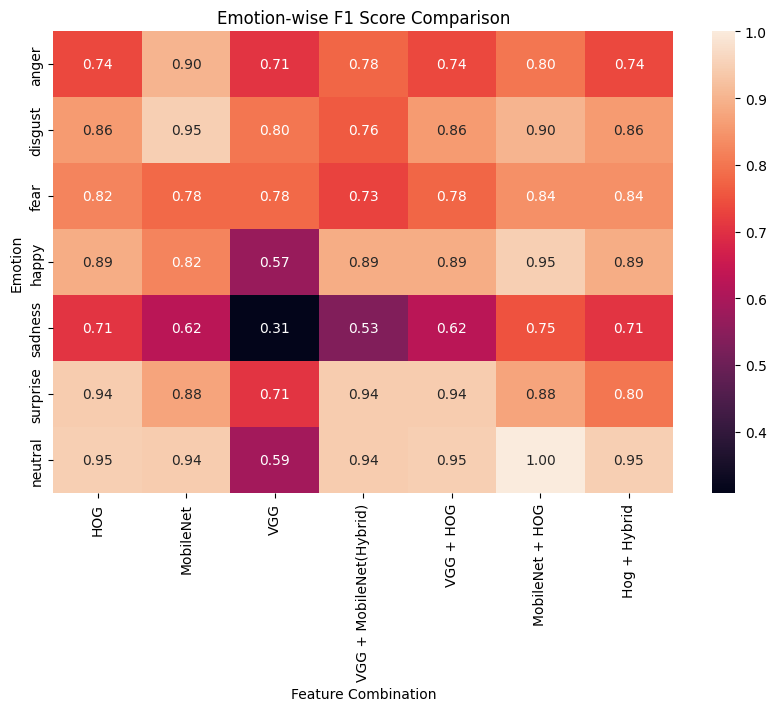

In [22]:
plt.figure(figsize=(10,6))

sns.heatmap(
    emotion_f1,
    annot=True,
    # cmap='YlGnBu',
    fmt='.2f'
)

plt.title("Emotion-wise F1 Score Comparison")
plt.xlabel("Feature Combination")
plt.ylabel("Emotion")

plt.show()

In [23]:
best_models = {}

for emotion in emotion_names:

    best_model = emotion_f1.loc[emotion].idxmax()
    best_score = emotion_f1.loc[emotion].max()

    best_models[emotion] = (best_model, best_score)

print("\n=== BEST FEATURE SET FOR EACH EMOTION ===\n")

for emotion, (model, score) in best_models.items():
    print(f"{emotion}: {model} ({score:.2f})")


=== BEST FEATURE SET FOR EACH EMOTION ===

anger: MobileNet (0.90)
disgust: MobileNet (0.95)
fear: MobileNet + HOG (0.84)
happy: MobileNet + HOG (0.95)
sadness: MobileNet + HOG (0.75)
surprise: HOG (0.94)
neutral: MobileNet + HOG (1.00)


In [24]:
# emotion_f1.T.plot(
#     kind='bar',
#     figsize=(14,6)
# )

# plt.title("Feature Combination vs Emotion Performance")
# plt.ylabel("F1 Score")
# plt.xticks(rotation=30)

# plt.legend(title='Emotion')
# plt.show()

In [25]:
def run_model_cv(X, name):

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='linear'))
    ])

    y_pred = cross_val_predict(
        model,
        X,
        labels,
        cv=10
    )

    acc = accuracy_score(labels, y_pred)

    print(f"\n{name} Accuracy: {acc:.4f}")

    report = classification_report(
        labels,
        y_pred,
        target_names=emotion_names,
        output_dict=True
    )

    cm = confusion_matrix(labels, y_pred)

    return {
        'name': name,
        'accuracy': acc,
        'report': report,
        'cm': cm,
        'y_pred': y_pred
    }

In [26]:
results = []

results.append(run_model_cv(X_hog, "HOG"))

results.append(run_model_cv(X_cnn, "MobileNet"))

results.append(run_model_cv(X_vgg, "VGG"))

results.append(run_model_cv(X_hybrid, "VGG + MobileNet"))

results.append(run_model_cv(X_hog_vgg, "VGG + HOG"))

results.append(run_model_cv(X_hog_cnn, "MobileNet + HOG"))

results.append(run_model_cv(X_final, "Hog + hybrid"))


HOG Accuracy: 0.8873

MobileNet Accuracy: 0.8592

VGG Accuracy: 0.7418

VGG + MobileNet Accuracy: 0.8685

VGG + HOG Accuracy: 0.8779

MobileNet + HOG Accuracy: 0.9014

Hog + hybrid Accuracy: 0.9061


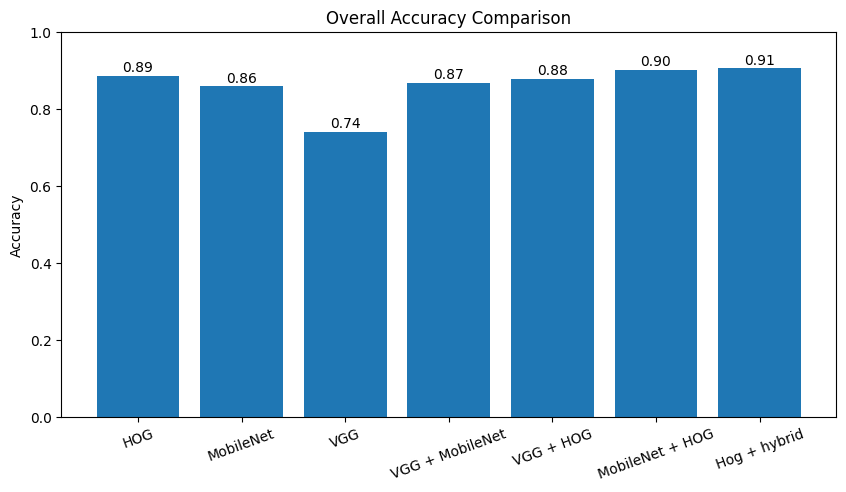

In [27]:
model_names = []
accuracies = []

for res in results:
    model_names.append(res['name'])
    accuracies.append(res['accuracy'])

plt.figure(figsize=(10,5))

bars = plt.bar(model_names, accuracies)

plt.ylim(0,1)

plt.title("Overall Accuracy Comparison")
plt.ylabel("Accuracy")

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        f"{yval:.2f}",
        ha='center'
    )

plt.xticks(rotation=20)

plt.show()

In [28]:
emotion_f1 = pd.DataFrame()

for res in results:

    model_name = res['name']

    f1_scores = []

    for emotion in emotion_names:

        f1_scores.append(
            res['report'][emotion]['f1-score']
        )

    emotion_f1[model_name] = f1_scores

emotion_f1.index = emotion_names

print(emotion_f1)

               HOG  MobileNet       VGG  VGG + MobileNet  VGG + HOG  \
anger     0.896552   0.935484  0.754098         0.935484   0.896552   
disgust   0.813559   0.836364  0.709677         0.872727   0.813559   
fear      0.843750   0.869565  0.878788         0.952381   0.830769   
happy     0.953846   0.903226  0.590164         0.852459   0.953846   
sadness   0.833333   0.714286  0.644068         0.754098   0.827586   
surprise  0.933333   0.857143  0.830189         0.857143   0.915254   
neutral   0.933333   0.878788  0.781250         0.852941   0.903226   

          MobileNet + HOG  Hog + hybrid  
anger            0.949153      0.949153  
disgust          0.827586      0.807018  
fear             0.843750      0.857143  
happy            0.953846      0.953846  
sadness          0.866667      0.903226  
surprise         0.912281      0.912281  
neutral          0.952381      0.952381  


In [29]:
# emotion_f1 = pd.DataFrame()

# for res in results:

#     model_name = res['name']

#     f1_scores = []

#     for emotion in emotion_names:

#         f1_scores.append(
#             res['report'][emotion]['f1-score']
#         )

#     emotion_f1[model_name] = f1_scores

# emotion_f1.index = emotion_names

# print(emotion_f1)

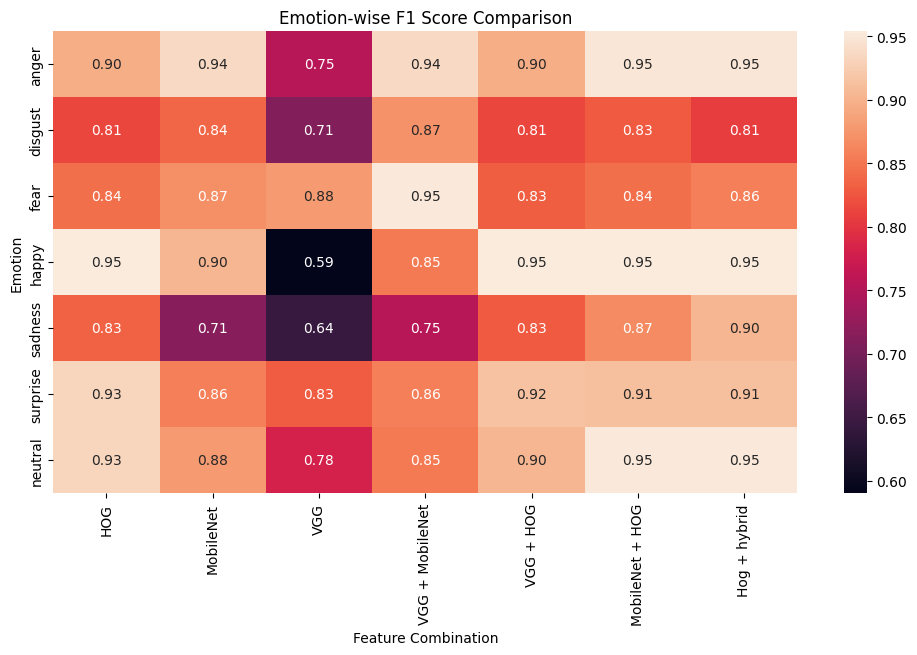

In [30]:
plt.figure(figsize=(12,6))

sns.heatmap(
    emotion_f1,
    annot=True,
    # cmap='YlGnBu',
    fmt='.2f'
)

plt.title("Emotion-wise F1 Score Comparison")
plt.xlabel("Feature Combination")
plt.ylabel("Emotion")

plt.show()

In [31]:
print("\n=== BEST FEATURE SET FOR EACH EMOTION ===\n")

for emotion in emotion_names:

    best_model = emotion_f1.loc[emotion].idxmax()

    best_score = emotion_f1.loc[emotion].max()

    print(
        f"{emotion}: "
        f"{best_model} "
        f"({best_score:.2f})"
    )


=== BEST FEATURE SET FOR EACH EMOTION ===

anger: MobileNet + HOG (0.95)
disgust: VGG + MobileNet (0.87)
fear: VGG + MobileNet (0.95)
happy: HOG (0.95)
sadness: Hog + hybrid (0.90)
surprise: HOG (0.93)
neutral: MobileNet + HOG (0.95)


In [32]:
# emotion_f1.T.plot(
#     kind='bar',
#     figsize=(14,6)
# )

# plt.title("Feature Combination vs Emotion Performance")

# plt.ylabel("F1 Score")

# plt.xticks(rotation=20)

# plt.legend(title='Emotion')

# plt.show()

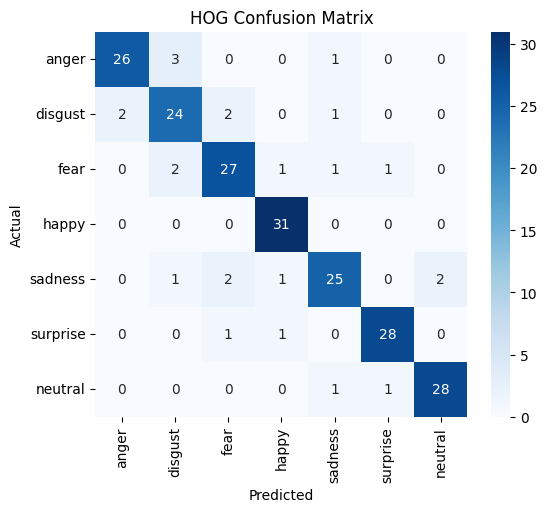

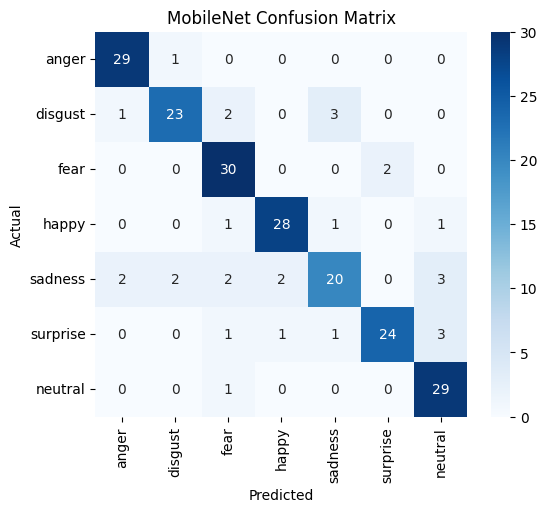

In [33]:
important_models = [
    'HOG',
    'MobileNet',
    'All Features'
]

for res in results:

    if res['name'] in important_models:

        plt.figure(figsize=(6,5))

        sns.heatmap(
            res['cm'],
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=emotion_names,
            yticklabels=emotion_names
        )

        plt.title(f"{res['name']} Confusion Matrix")

        plt.xlabel("Predicted")
        plt.ylabel("Actual")

        plt.show()

In [34]:
upper_faces = []
lower_faces = []

for img in data:

    # # Upper face
    upper = img[25:70, :]
    # Lower 
    lower = img[88:130, :]

    # Resize back to 128x128
    # upper = cv2.resize(upper, (128,128))
    # lower = cv2.resize(lower, (128,128))

    upper_faces.append(upper)
    lower_faces.append(lower)

upper_faces = np.array(upper_faces)
lower_faces = np.array(lower_faces)

print("Upper shape:", upper_faces.shape)
print("Lower shape:", lower_faces.shape)

Upper shape: (213, 45, 128)
Lower shape: (213, 40, 128)


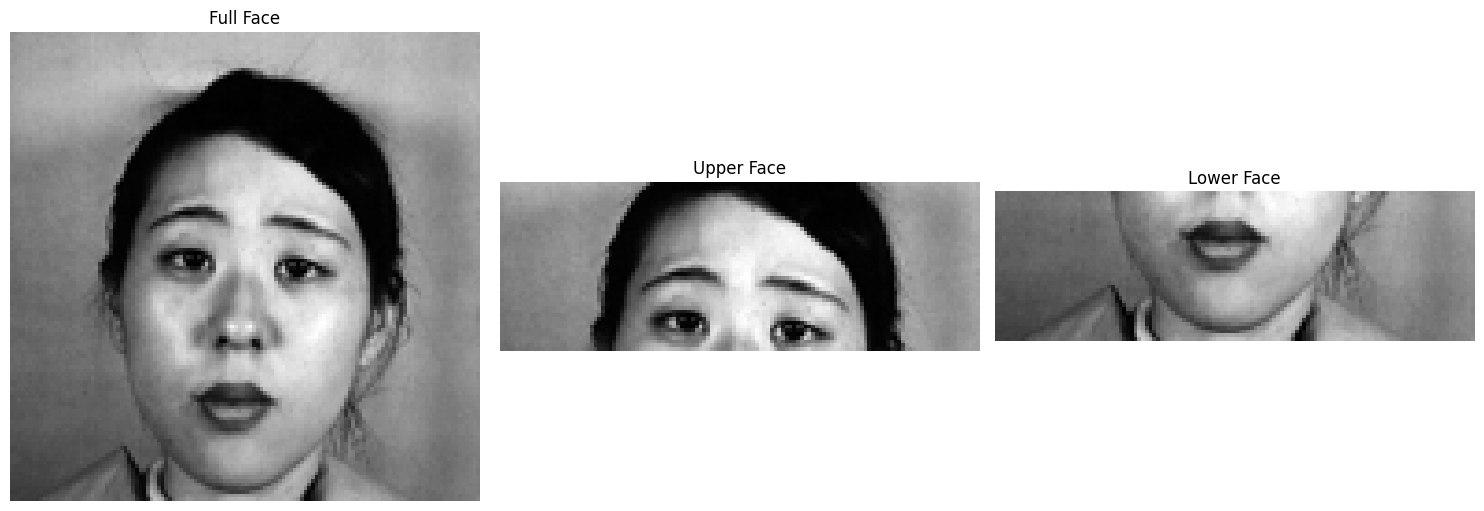

In [35]:
sample = 0

fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(data[sample], cmap='gray')
ax[0].set_title("Full Face")

ax[1].imshow(upper_faces[sample], cmap='gray')
ax[1].set_title("Upper Face")

ax[2].imshow(lower_faces[sample], cmap='gray')
ax[2].set_title("Lower Face")

for a in ax:
    a.axis('off')

plt.tight_layout()
plt.show()

In [36]:
# =========================================
# UPPER FACE FEATURES
# =========================================

# ---------- HOG ----------
X_hog_upper = []

for img in upper_faces:

    feat = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )

    X_hog_upper.append(feat)

X_hog_upper = np.array(X_hog_upper)


# ---------- MobileNet ----------
X_cnn_upper = extract_cnn_features(
    upper_faces,
    mobilenet
)


# ---------- VGG ----------
X_vgg_upper = extract_vgg_features(
    upper_faces,
    vgg
)


# ---------- MobileNet + HOG ----------
X_upper_mob_hog = np.concatenate(
    [X_hog_upper, X_cnn_upper],
    axis=1
)


# ---------- All Features ----------
X_upper_all = np.concatenate(
    [X_hog_upper,
     X_cnn_upper,
     X_vgg_upper],
    axis=1
)

print("Upper face features ready.")

Upper face features ready.


In [37]:
# =========================================
# LOWER FACE FEATURES
# =========================================

# ---------- HOG ----------
X_hog_lower = []

for img in lower_faces:

    feat = hog(
        img,
        orientations=9,
        pixels_per_cell=(8,8),
        cells_per_block=(2,2)
    )

    X_hog_lower.append(feat)

X_hog_lower = np.array(X_hog_lower)


# ---------- MobileNet ----------
X_cnn_lower = extract_cnn_features(
    lower_faces,
    mobilenet
)


# ---------- VGG ----------
X_vgg_lower = extract_vgg_features(
    lower_faces,
    vgg
)


# ---------- MobileNet + HOG ----------
X_lower_mob_hog = np.concatenate(
    [X_hog_lower, X_cnn_lower],
    axis=1
)


# ---------- All Features ----------
X_lower_all = np.concatenate(
    [X_hog_lower,
     X_cnn_lower,
     X_vgg_lower],
    axis=1
)

print("Lower face features ready.")

Lower face features ready.


In [38]:
def run_region_models(region_name,
                      X_hog,
                      X_mob_hog,
                      X_all):

    region_results = []

    # HOG
    region_results.append(
        run_model_cv(
            X_hog,
            f"{region_name} HOG"
        )
    )

    # MobileNet + HOG
    region_results.append(
        run_model_cv(
            X_mob_hog,
            f"{region_name} MobileNet + HOG"
        )
    )

    # All Features
    region_results.append(
        run_model_cv(
            X_all,
            f"{region_name} Hog+Hybrid"
        )
    )

    return region_results

In [39]:
upper_results = run_region_models(
    "Upper",
    X_hog_upper,
    X_upper_mob_hog,
    X_upper_all
)

lower_results = run_region_models(
    "Lower",
    X_hog_lower,
    X_lower_mob_hog,
    X_lower_all
)


Upper HOG Accuracy: 0.7840

Upper MobileNet + HOG Accuracy: 0.8779

Upper Hog+Hybrid Accuracy: 0.8967

Lower HOG Accuracy: 0.7981

Lower MobileNet + HOG Accuracy: 0.8685

Lower Hog+Hybrid Accuracy: 0.8685


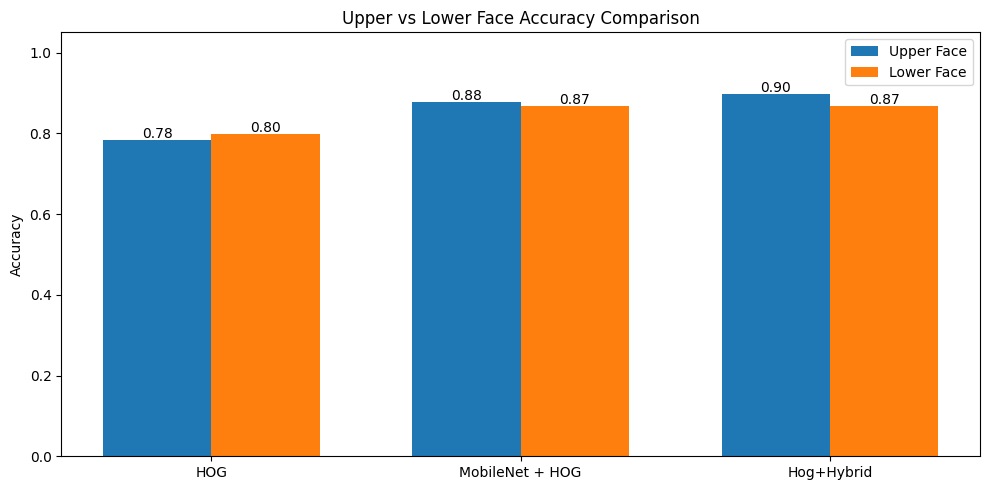

In [40]:
upper_acc = []
lower_acc = []
models = []

for i in range(len(upper_results)):

    model_name = upper_results[i]['name']

    # remove region prefix
    model_name = model_name.replace("Upper ", "")

    models.append(model_name)

    upper_acc.append(
        upper_results[i]['accuracy']
    )

    lower_acc.append(
        lower_results[i]['accuracy']
    )

x = np.arange(len(models))

width = 0.35

plt.figure(figsize=(10,5))

# Bars
bars1 = plt.bar(
    x - width/2,
    upper_acc,
    width,
    label='Upper Face'
)

bars2 = plt.bar(
    x + width/2,
    lower_acc,
    width,
    label='Lower Face'
)

# Add values on bars
for bar in bars1:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f'{height:.2f}',
        ha='center',
        fontsize=10
    )

for bar in bars2:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f'{height:.2f}',
        ha='center',
        fontsize=10
    )

# Labels
plt.xticks(x, models)

plt.ylabel("Accuracy")

# plt.xlabel("Feature Combination")

plt.title("Upper vs Lower Face Accuracy Comparison")

plt.ylim(0, 1.05)

plt.legend()

plt.tight_layout()

plt.show()

In [41]:
def create_emotion_heatmap(results, title):

    emotion_f1 = pd.DataFrame()

    for res in results:

        model_name = res['name']

        # Remove region prefix
        model_name = model_name.replace("Upper ", "")
        model_name = model_name.replace("Lower ", "")

        f1_scores = []

        for emotion in emotion_names:

            f1_scores.append(
                res['report'][emotion]['f1-score']
            )

        emotion_f1[model_name] = f1_scores

    emotion_f1.index = emotion_names

    plt.figure(figsize=(7,5))

    sns.heatmap(
        emotion_f1,
        annot=True,
        cmap='YlGnBu',
        fmt='.2f'
    )

    plt.title(title)

    plt.xlabel("Feature Combination")
    plt.ylabel("Emotion")

    plt.show()

    return emotion_f1

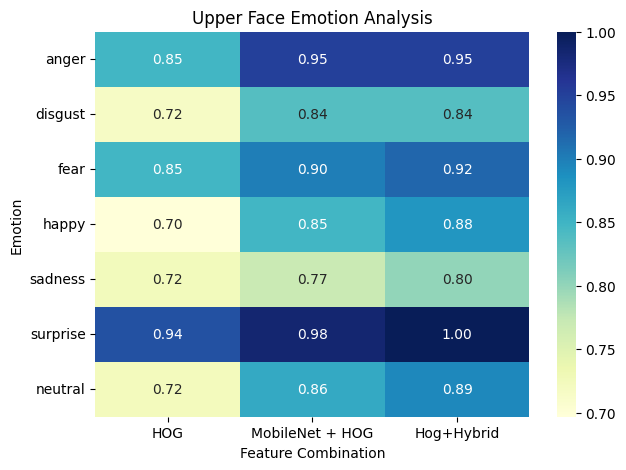

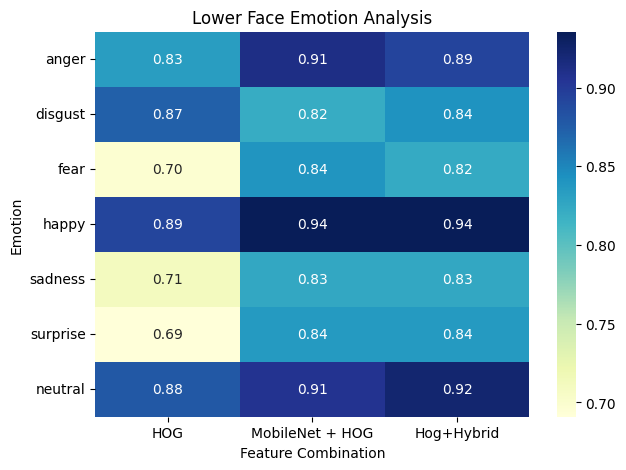

In [42]:
upper_heatmap = create_emotion_heatmap(
    upper_results,
    "Upper Face Emotion Analysis"
)

lower_heatmap = create_emotion_heatmap(
    lower_results,
    "Lower Face Emotion Analysis"
)